# Import all the required libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import datetime as dt
from datetime import date
import yfinance as yf
import tensorflow as tf

# Data Collection Module

Download the data from yahoo finance

In [2]:
START = "2010-01-01"
TODAY = date.today().strftime("%Y-%m-%d")

# Define a function to load the dataset
def load_data(ticker):
    data = yf.download(ticker, START, TODAY)
    data.reset_index(inplace=True)
    return data

Apple Stock

In [3]:
data = load_data('AAPL')
df=data
df.head()

/tmp/ipython-input-3947578972.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, START, TODAY)
[*********************100%***********************]  1 of 1 completed


Price,Date,Close,High,Low,Open,Volume
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL
0,2010-01-04,6.418384,6.433080,6.369499,6.400989,493729600
1,2010-01-05,6.429480,6.465769,6.395589,6.436078,601904800
2,2010-01-06,6.327210,6.454972,6.320612,6.429479,552160000
3,2010-01-07,6.315513,6.358101,6.269627,6.350603,477131200
4,2010-01-08,6.357501,6.358101,6.269928,6.307116,447610800


In [4]:
print(df.columns) #Checking Column names

MultiIndex([(  'Date',     ''),
            ( 'Close', 'AAPL'),
            (  'High', 'AAPL'),
            (   'Low', 'AAPL'),
            (  'Open', 'AAPL'),
            ('Volume', 'AAPL')],
           names=['Price', 'Ticker'])


In [5]:
#Overall Info of the Dataset
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4001 entries, 0 to 4000
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   (Date, )        4001 non-null   datetime64[ns]
 1   (Close, AAPL)   4001 non-null   float64       
 2   (High, AAPL)    4001 non-null   float64       
 3   (Low, AAPL)     4001 non-null   float64       
 4   (Open, AAPL)    4001 non-null   float64       
 5   (Volume, AAPL)  4001 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 187.7 KB


In [6]:
#Statistics of the Dataset
df.describe()

Price,Date,Close,High,Low,Open,Volume
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL
count,4001,4001.000000,4001.000000,4001.000000,4001.000000,4.001000e+03
mean,2017-12-13 20:07:51.482129408,76.367354,77.127053,75.535327,76.301140,2.200235e+08
min,2010-01-04 00:00:00,5.759781,5.878244,5.705797,5.769377,2.323470e+07
25%,2013-12-23 00:00:00,18.192360,18.315224,18.006023,18.153582,7.875130e+07
50%,2017-12-12 00:00:00,38.180305,38.534821,37.771600,38.194358,1.317456e+08
75%,2021-12-02 00:00:00,142.145554,143.589188,140.165432,141.416078,2.913684e+08
max,2025-11-26 00:00:00,277.549988,280.380005,276.630005,276.959991,1.880998e+09
std,NaN,73.709189,74.433740,72.904262,73.622273,2.156726e+08


Outliers

-----------

In [7]:
Q1 = df['Close'].quantile(0.25)
Q3 = df['Close'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df['Close'] = np.where(df['Close'] > upper, upper,
                np.where(df['Close'] < lower, lower, df['Close']))

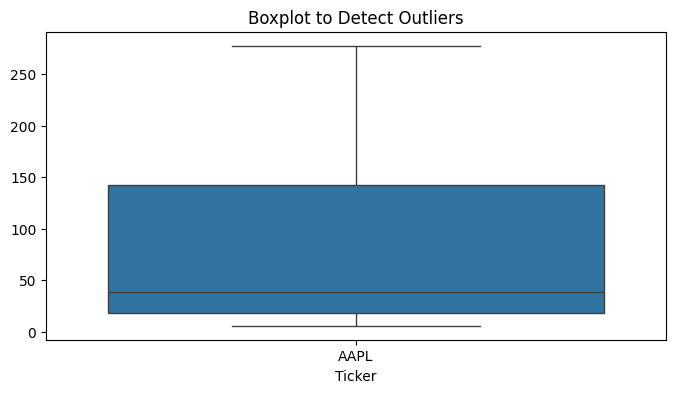

In [8]:
plt.figure(figsize=(8,4))
sns.boxplot(df['Close'])
plt.title("Boxplot to Detect Outliers")
plt.show()

Missing Value Handling

In [9]:
df.isnull().sum() #No Missing Value in Dataset

,,0
Price,Ticker,
Date,,0
Close,AAPL,0
High,AAPL,0
Low,AAPL,0
Open,AAPL,0
Volume,AAPL,0


Visualizing Closing Price

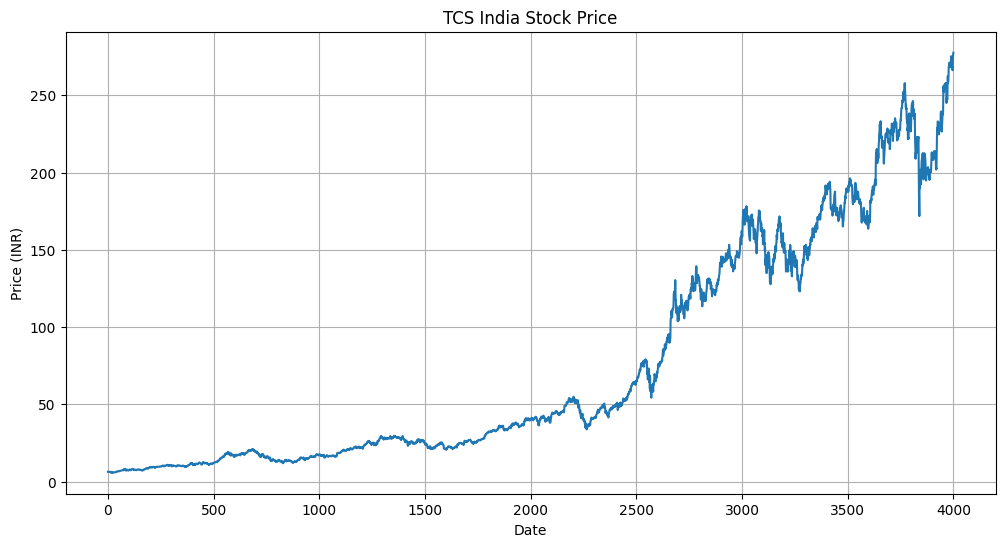

In [10]:
plt.figure(figsize=(12, 6))
plt.plot(df['Close'])
plt.title("TCS India Stock Price")
plt.xlabel("Date")
plt.ylabel("Price (INR)")
plt.grid(True)
plt.show()

# Feature Engineering

Plotting moving averages of 100 day

In [11]:
ma100 = df.Close.rolling(100).mean()
ma100

Ticker,AAPL
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
3996,239.443123
3997,240.038086
3998,240.666273
3999,241.340884


Text(0.5, 1.0, 'Graph Of Moving Averages Of 100 Days')

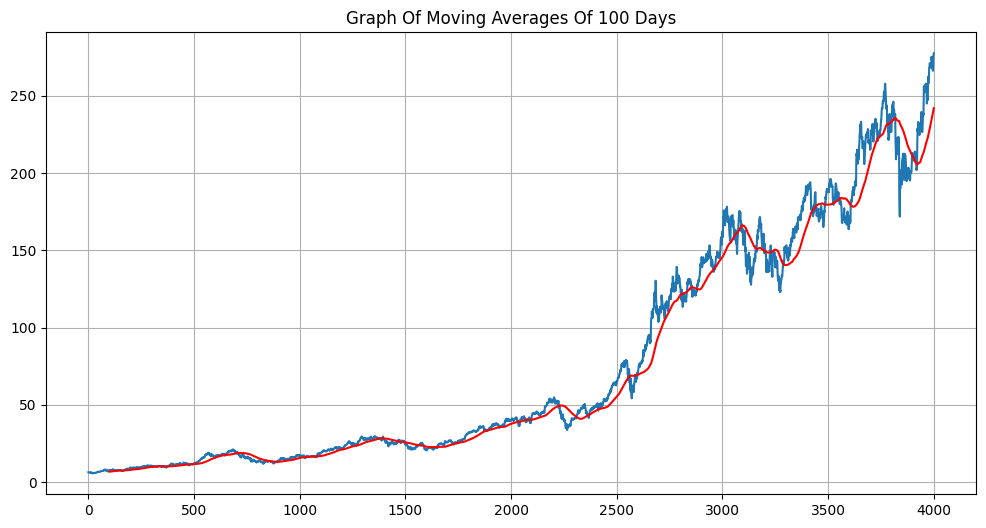

In [12]:
plt.figure(figsize = (12,6))
plt.plot(df.Close)
plt.plot(ma100, 'r')
plt.grid(True)
plt.title('Graph Of Moving Averages Of 100 Days')

Defining 200 days moving averages and plotting comparision graph with 100 days moving averages

In [13]:
ma200 = df.Close.rolling(200).mean()
ma200

Ticker,AAPL
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
3996,225.623173
3997,225.819773
3998,226.066347
3999,226.316826


Text(0.5, 1.0, 'Comparision Of 100 Days And 200 Days Moving Averages')

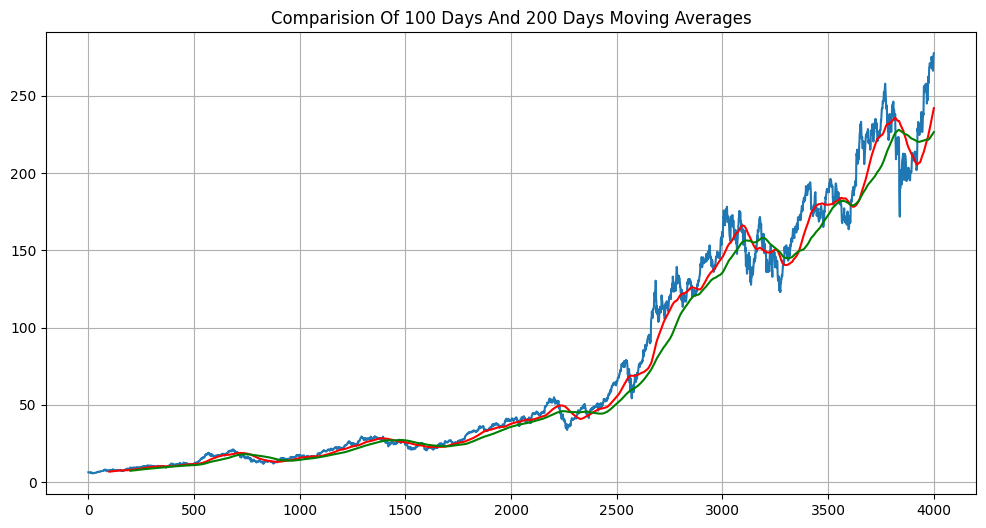

In [14]:
plt.figure(figsize = (12,6))
plt.plot(df.Close)
plt.plot(ma100, 'r')
plt.plot(ma200, 'g')
plt.grid(True)
plt.title('Comparision Of 100 Days And 200 Days Moving Averages')

RSI (Relative Strength Index)

In [15]:
delta = df['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
rs = gain / loss
df['RSI'] = 100 - (100 / (1 + rs))

# Data Preprocessing and Splitting

Splitting into 70% and 30%

In [16]:
# Splitting data into training and testing

train = pd.DataFrame(data[0:int(len(data)*0.70)])
test = pd.DataFrame(data[int(len(data)*0.70): int(len(data))])

print(train.shape)
print(test.shape)

(2800, 7)
(1201, 7)


In [17]:
train.head()

Price,Date,Close,High,Low,Open,Volume,RSI
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,
0,2010-01-04,6.418384,6.433080,6.369499,6.400989,493729600,NaN
1,2010-01-05,6.429480,6.465769,6.395589,6.436078,601904800,NaN
2,2010-01-06,6.327210,6.454972,6.320612,6.429479,552160000,NaN
3,2010-01-07,6.315513,6.358101,6.269627,6.350603,477131200,NaN
4,2010-01-08,6.357501,6.358101,6.269928,6.307116,447610800,NaN


In [18]:
test.head()

Price,Date,Close,High,Low,Open,Volume,RSI
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,
2800,2021-02-18,126.455193,126.737909,124.212904,125.957980,96856700,32.830502
2801,2021-02-19,126.611168,127.430101,125.568025,126.971894,87668800,44.059372
2802,2021-02-22,122.838264,126.464919,122.448300,124.797822,103916400,27.477805
2803,2021-02-23,122.701775,123.530444,115.419219,120.654472,158273000,23.612451
2804,2021-02-24,122.204597,122.409327,119.162892,121.804889,111039900,24.388678


Normalize Data using MaxMinScaler

In [19]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))

In [20]:
train_close = train.iloc[:, 4:5].values
test_close = test.iloc[:, 4:5].values

In [21]:
data_training_array = scaler.fit_transform(train_close)
data_training_array

array([[0.00471288],
       [0.0049747 ],
       [0.00492546],
       ...,
       [0.93427015],
       [0.94256311],
       [0.9117196 ]])

Sliding Window Sequence

In [22]:
window_size = 60

x_train = []
y_train = []

for i in range(window_size, data_training_array.shape[0]):
    x_train.append(data_training_array[i-window_size : i])
    y_train.append(data_training_array[i, 0])

x_train, y_train = np.array(x_train), np.array(y_train)

In [23]:
x_train.shape

(2740, 60, 1)

# ML Model - LSTM

In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense
import tensorflow as tf

LSTM Model Architecture

In [25]:
model = Sequential()

#1st Layer
model.add(LSTM(
    units=64,
    return_sequences=True,
    input_shape=(x_train.shape[1], x_train.shape[2])
))

#2nd Layer
model.add(Dropout(0.2))
model.add(LSTM(
    units=64,
    return_sequences=True
))

#3rd Layer
model.add(Dropout(0.2))
model.add(LSTM(
    units=32
))

#Output layer
model.add(Dropout(0.2))
model.add(Dense(
    units=1
))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Compile Model

In [26]:
model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=[tf.keras.metrics.MeanAbsoluteError()]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 60, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,369 (243.63 KB)

 Trainable params: 62,369 (243.63 KB)

 Non-trainable params: 0 (0.00 B)

Train Model

In [27]:
history = model.fit(
    x_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True
        )
    ]
)

Epoch 1/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 15s 105ms/step - loss: 0.0052 - mean_absolute_error: 0.0464 - val_loss: 0.0030 - val_mean_absolute_error: 0.0441
Epoch 2/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 9s 111ms/step - loss: 5.5904e-04 - mean_absolute_error: 0.0161 - val_loss: 0.0044 - val_mean_absolute_error: 0.0559
Epoch 3/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 10s 110ms/step - loss: 4.3401e-04 - mean_absolute_error: 0.0136 - val_loss: 0.0023 - val_mean_absolute_error: 0.0351
Epoch 4/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 9s 92ms/step - loss: 4.8718e-04 - mean_absolute_error: 0.0148 - val_loss: 0.0020 - val_mean_absolute_error: 0.0335
Epoch 5/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 8s 108ms/step - loss: 4.6524e-04 - mean_absolute_error: 0.0138 - val_loss: 0.0019 - val_mean_absolute_error: 0.0330
Epoch 6/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 8s 107ms/step - loss: 3.7406e-04 - mean_absolute_error: 0.0128 - val_loss: 0.0023 - val_mean_absolute_error: 0.0396
Epoch 7/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 8s 97ms/step - loss: 4.1465e-04 - mean_ab

In [28]:
model.save("keras_model.h5")

In [30]:
window_size = 60
# Take the last 60 days from training data
past_60_days = train_close[-window_size:]

# Convert past_60_days to DataFrame
past_60_days_df = pd.DataFrame(past_60_days)

# Convert test close into DataFrame
test_df = pd.DataFrame(test_close)

# Combine last 60 days of training + all test data
final_df = pd.concat([past_60_days_df, test_df], ignore_index=True)

input_data = scaler.transform(final_df)

print("Final DF shape:", final_df.shape)
print("Input data shape:", input_data.shape)

Final DF shape: (1261, 1)
Input data shape: (1261, 1)


# Testing the model


In [31]:
window_size = 60   # MUST match training window

x_test = []
y_test = []

for i in range(window_size, input_data.shape[0]):
    x_test.append(input_data[i-window_size : i])
    y_test.append(input_data[i, 0])   # predicting close price

x_test = np.array(x_test)
y_test = np.array(y_test)

print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

x_test shape: (1201, 60, 1)
y_test shape: (1201,)


# Making prediction and plotting the graph of predicted vs actual values

In [32]:
# predictions
y_pred = model.predict(x_test)

38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step


In [33]:
# 2. Inverse scaling

# y_pred and y_test are 1D, but inverse_transform needs 2D
y_pred_scaled = scaler.inverse_transform(
    np.concatenate([y_pred, np.zeros((len(y_pred), input_data.shape[1]-1))], axis=1)
)[:, 0]

y_test_scaled = scaler.inverse_transform(
    np.concatenate([y_test.reshape(-1, 1), np.zeros((len(y_test), input_data.shape[1]-1))], axis=1)
)[:, 0]

# Model Evaluation

In [35]:
from sklearn.metrics import mean_absolute_error, r2_score

Calculation of mean absolute error (MAE)

In [36]:
mae = mean_absolute_error(y_test, y_pred)
mae_percentage = (mae / np.mean(y_test)) * 100
print("Mean absolute error on test set: {:.2f}%".format(mae_percentage))

Mean absolute error on test set: 2.74%


R2 Score

In [40]:
actual = y_test
predicted = y_pred
r2 = r2_score(actual, predicted)
print("R2 Score:", r2)

R2 Score: 0.9701294747278658


R2 BAR PLOT

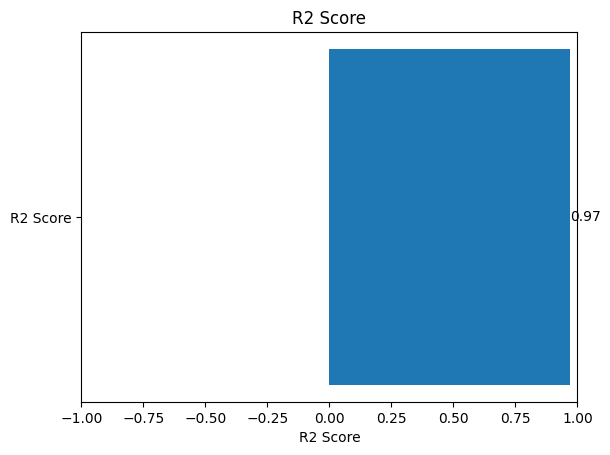

In [41]:
fig, ax = plt.subplots()
ax.barh(["R2 Score"], [r2])
ax.set_xlim([-1, 1])
ax.set_xlabel("R2 Score")
ax.set_title("R2 Score")
ax.text(r2, 0, f"{r2:.2f}", va='center')
plt.show()

# Prediction Accuracy Matrics


In [44]:
from sklearn.metrics import mean_squared_error
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
r2 = r2_score(y_test, y_pred)

accuracy = 100 - mape  # regression-style accuracy

# Summary Table
metrics_table = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "MAPE (%)", "Accuracy (%)", "R2 Score"],
    "Value": [mae, mse, rmse, mape, accuracy, r2]
})

print(metrics_table)

         Metric      Value
0           MAE   0.035411
1           MSE   0.002379
2          RMSE   0.048771
3      MAPE (%)  24.293331
4  Accuracy (%)  75.706669
5      R2 Score   0.970129


# Original Price & Predicted Price

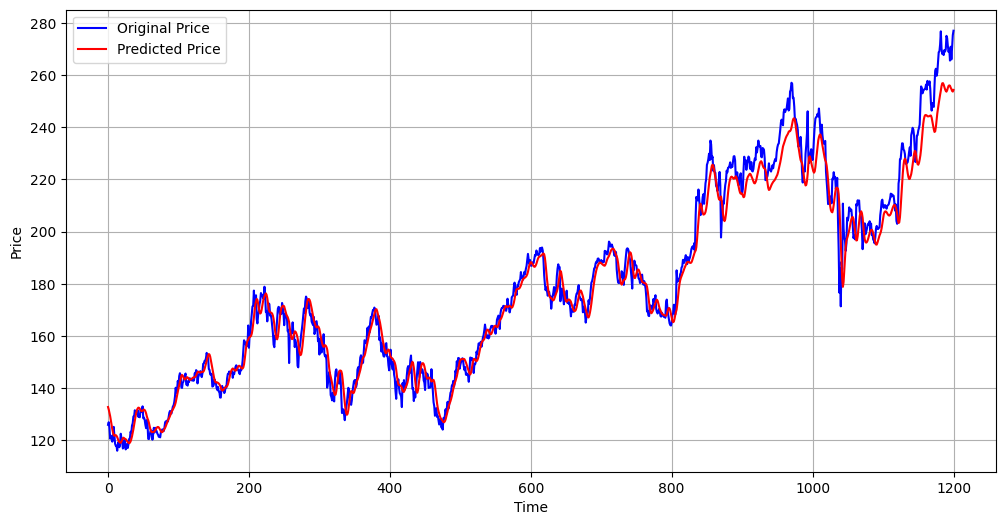

In [34]:
plt.figure(figsize=(12,6))
plt.plot(y_test_scaled, 'b', label='Original Price')
plt.plot(y_pred_scaled, 'r', label='Predicted Price')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

# Candlestick Charts

In [45]:
# Get test section based on your split
df_test = df.iloc[int(len(df)*0.70):].copy()

# Only keep rows where you generated predictions (ignore sliding warm-up)
df_test = df_test.iloc[-len(y_pred):].copy()

# Attach predicted close price
df_test["Predicted_Close"] = y_pred

In [57]:
import plotly.graph_objects as go

fig = go.Figure()

# Actual candlestick
fig.add_trace(go.Candlestick(
    x=df_test["Date"],
    open=df_test["Open"],
    high=df_test["High"],
    low=df_test["Low"],
    close=df_test["Close"],
    name="Actual Price"
))

# Predicted close line
fig.add_trace(go.Scatter(
    x=df_test["Date"],
    y=df_test["Predicted_Close"],
    mode='lines+markers',
    name='Predicted Close'
))

fig.update_layout(
    title="Stock Price Prediction - Candlestick Chart with Model Predictions",
    xaxis_title="Date",
    yaxis_title="Price",
    xaxis_rangeslider_visible=False
)

fig.show()

In [60]:
# Inverse transform the predictions
y_pred_rescaled = scaler.inverse_transform(y_pred.reshape(-1,1)).flatten()

# Inverse transform test Close price
y_test_rescaled = scaler.inverse_transform(y_test.reshape(-1,1)).flatten()

# Add to df_test
df_test["Predicted_Close"] = y_pred_rescaled

In [61]:
import plotly.graph_objects as go

fig = go.Figure()

# Actual OHLC Candlestick
fig.add_trace(go.Candlestick(
    x=df_test["Date"],
    open=df_test["Open"],
    high=df_test["High"],
    low=df_test["Low"],
    close=df_test["Close"],
    name="Actual Price"
))

# Predicted line
fig.add_trace(go.Scatter(
    x=df_test["Date"],
    y=df_test["Predicted_Close"],
    mode='lines',
    line=dict(width=2, color='orange'),
    name='Predicted Close'
))

fig.update_layout(
    title="Stock Price Prediction - Candlestick Chart with Model Predictions",
    xaxis_title="Date",
    yaxis_title="Price",
    xaxis_rangeslider_visible=False,
    template="plotly_dark",     # optional, for look like premium trading view charts
    height=700
)

fig.show()


# Save the Model

In [69]:
import json
import pickle
from tensorflow.keras.models import load_model

# Save LSTM Model
model.save("stock_lstm_model.h5")
print("Model saved as stock_lstm_model.h5")

# Save Scaler
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
print("Scaler saved as scaler.pkl")

look_back = 60
feature_columns = ["Close"]

# Save configuration
config = {
    "look_back": look_back,
    "feature_columns": feature_columns,
    "target_column": "Close",
    "train_test_split": 0.70
}

with open("config.json", "w") as f:
    json.dump(config, f, indent=4)

print("Config saved as config.json")

Model saved as stock_lstm_model.h5
Scaler saved as scaler.pkl
Config saved as config.json


In [68]:
from google.colab import files
files.download("stock_lstm_model.h5")
files.download("config.json")
files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [70]:
import os
os.makedirs("data", exist_ok=True)

df.to_csv("data/stock_price.csv", index=False)
print("CSV saved successfully!")

CSV saved successfully!
